# 🏠 California House Price Prediction Using Machine Learning

## Project Overview

The objective of this project is to predict California housing prices using regression models.

The project includes:

- Data Exploration
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Feature Scaling
- Regression Model Training
- Model Evaluation
- Model Comparison

## Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


Importing the California House Price

In [2]:
house_dataset=fetch_california_housing()

In [3]:
print(house_dataset)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]]), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset:\n\nCalifornia Housing dataset\n-

In [4]:
# Loading the dataset to a Pandas DataFrame
house_df = pd.DataFrame(
    house_dataset.data,
    columns=house_dataset.feature_names
)

In [5]:
house_df["Price"] = house_dataset.target

In [6]:
house_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
house_df.shape

(20640, 9)

In [8]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Dataset Inspection

In [9]:
house_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Missing Values

In [10]:
house_df.isnull().sum()


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


## Exploratory Data Analysis

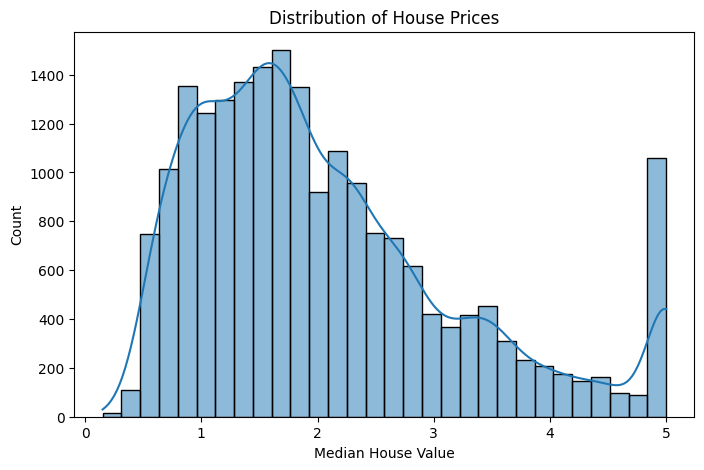

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(house_df["Price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.show()

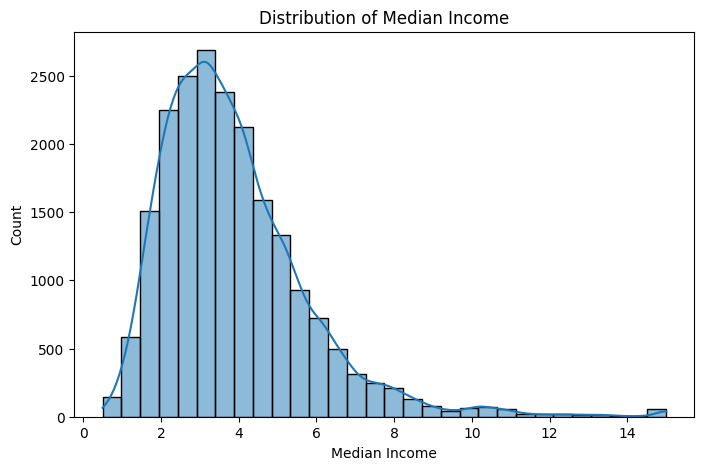

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    house_df["MedInc"],
    bins=30,
    kde=True
)

plt.title("Distribution of Median Income")
plt.xlabel("Median Income")
plt.ylabel("Count")
plt.show()

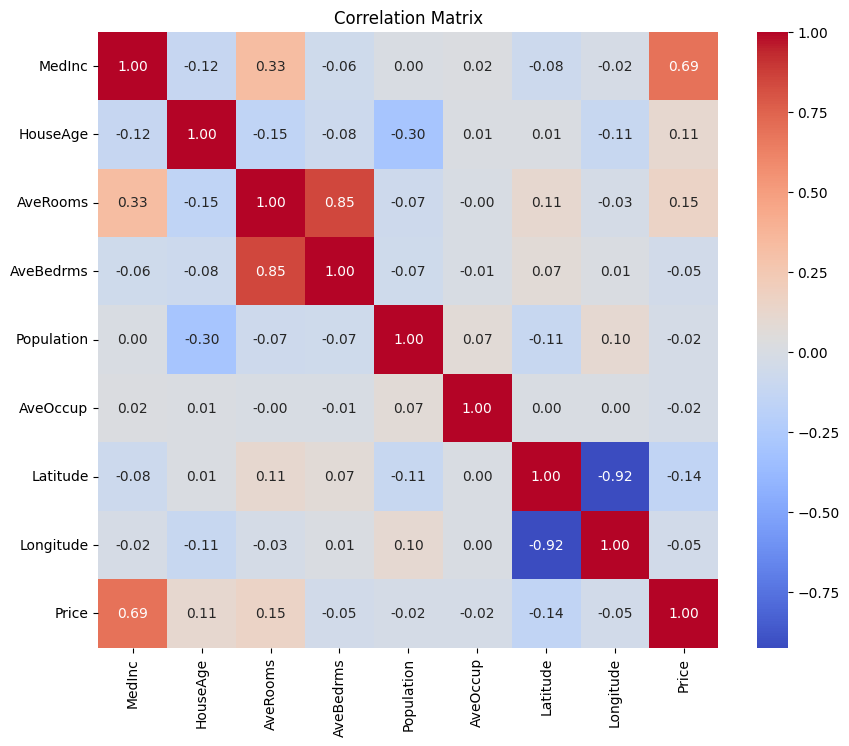

In [15]:
plt.figure(figsize=(10, 8))

correlation_matrix = house_df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

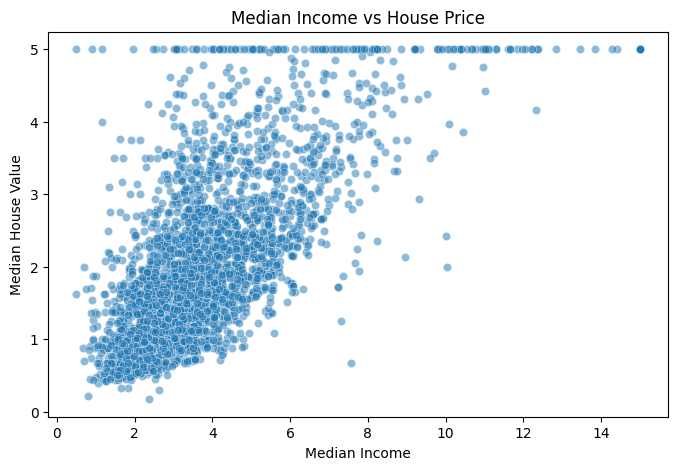

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=house_df.sample(3000, random_state=42),
    x="MedInc",
    y="Price",
    alpha=0.5
)

plt.title("Median Income vs House Price")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

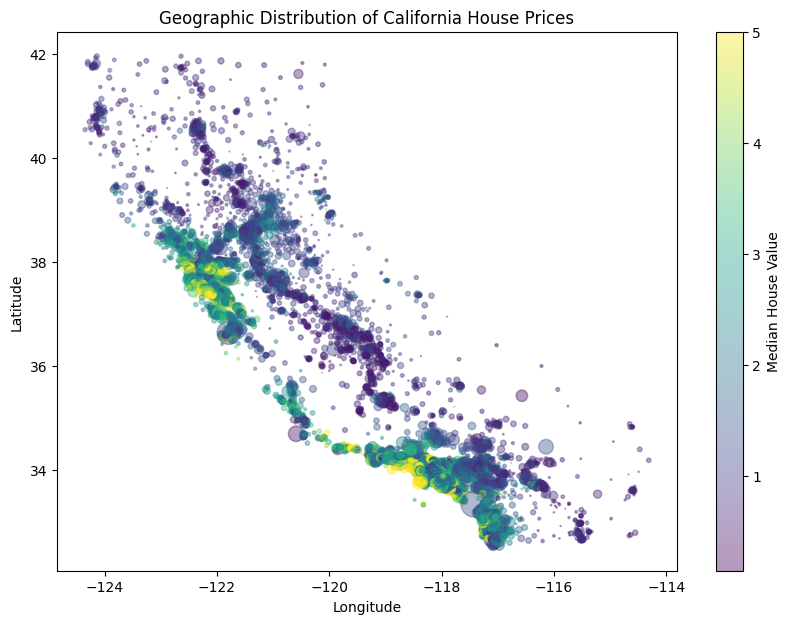

In [17]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    house_df["Longitude"],
    house_df["Latitude"],
    c=house_df["Price"],
    s=house_df["Population"] / 100,
    alpha=0.4,
    cmap="viridis"
)

plt.colorbar(scatter, label="Median House Value")
plt.title("Geographic Distribution of California House Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Features and Target

In [18]:
X = house_df.drop("Price", axis=1)
y = house_df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (16512, 8)
Testing set: (4128, 8)


In [19]:
X = house_df.drop("Price", axis=1)

y = house_df["Price"]

In [20]:
print(X.shape)

print(y.shape)

(20640, 8)
(20640,)


## Feature Scaling

In [21]:
# Scale features for Linear Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Linear Regression

In [22]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

LinearRegression()

In [23]:
linear_predictions = linear_model.predict(X_test_scaled)

In [24]:
linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

In [25]:
print("Linear Regression Results")
print(f"MAE: {linear_mae:.4f}")
print(f"RMSE: {linear_rmse:.4f}")
print(f"R² Score: {linear_r2:.4f}")

Linear Regression Results
MAE: 0.5332
RMSE: 0.7456
R² Score: 0.5758


## Random Forest Regressor

In [26]:
random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [27]:
rf_predictions = random_forest.predict(X_test)

In [28]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

In [29]:
print("Random Forest Results")
print(f"MAE: {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R² Score: {rf_r2:.4f}")

Random Forest Results
MAE: 0.3268
RMSE: 0.5040
R² Score: 0.8062


## Gradient Boosting Regressor

In [30]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=200, random_state=42)

In [31]:
gb_predictions = gradient_boosting.predict(X_test)

In [32]:
gb_mae = mean_absolute_error(y_test, gb_predictions)

gb_rmse = np.sqrt(
    mean_squared_error(y_test, gb_predictions)
)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

In [33]:
print("Gradient Boosting Results")
print(f"MAE: {gb_mae:.4f}")
print(f"RMSE: {gb_rmse:.4f}")
print(f"R² Score: {gb_r2:.4f}")

Gradient Boosting Results
MAE: 0.3483
RMSE: 0.5114
R² Score: 0.8004


## Model Performance Comparison

In [34]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R² Score": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.533200,0.745581,0.575788
1,Random Forest,0.326812,0.503960,0.806186
2,Gradient Boosting,0.348343,0.511369,0.800445


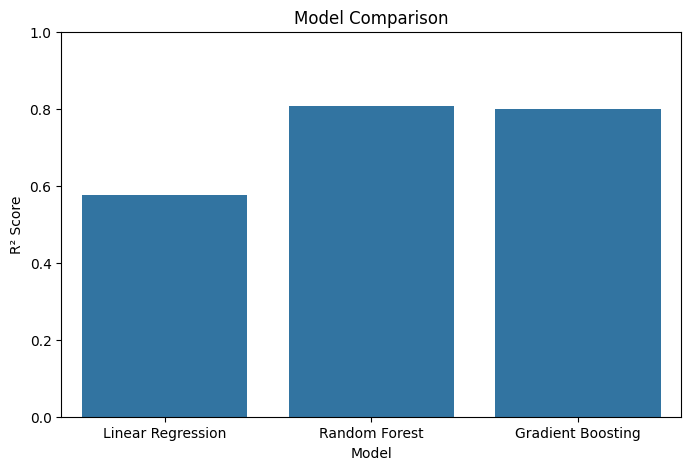

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R² Score"
)

plt.title("Model Comparison")
plt.ylim(0,1)

plt.show()

## Feature Importance

In [36]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

In [37]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [38]:
feature_importance

,Feature,Importance
0,MedInc,0.525886
5,AveOccup,0.138055
6,Latitude,0.088647
7,Longitude,0.088307
1,HouseAge,0.054355
2,AveRooms,0.044449
4,Population,0.030693
3,AveBedrms,0.029608


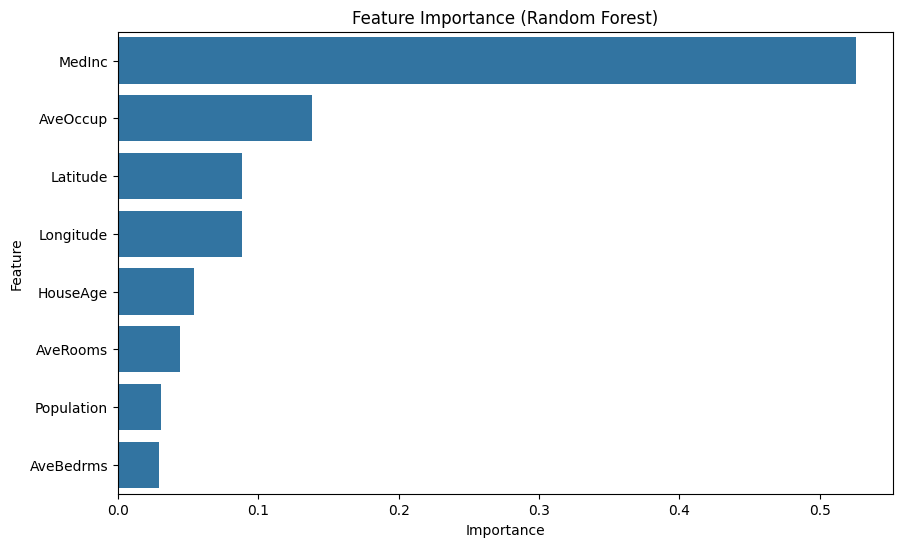

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Actual vs Predicted Values

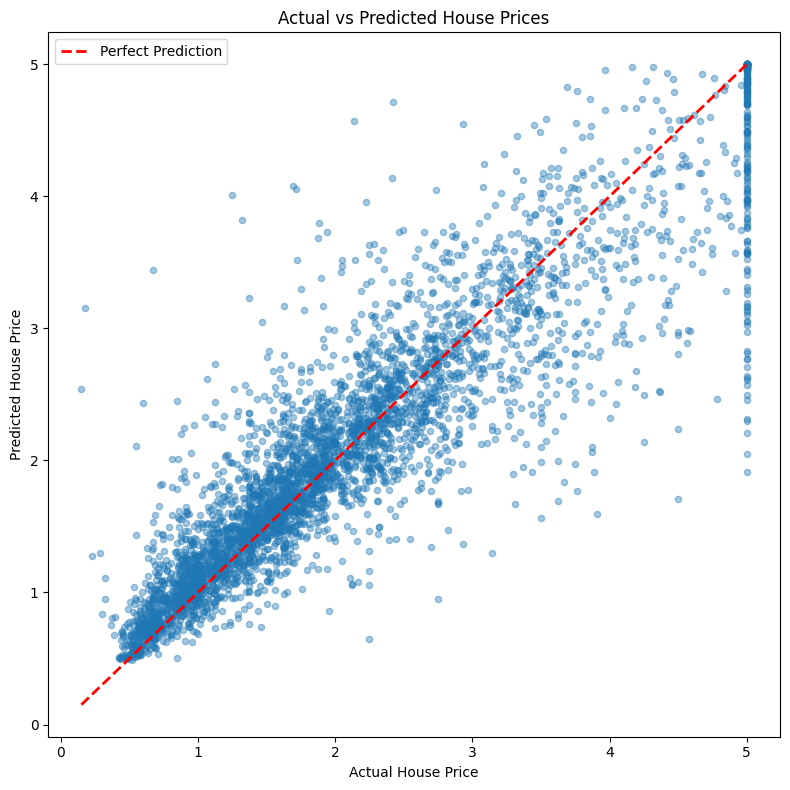

In [43]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.4,
    s=20
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.legend()

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.tight_layout()

plt.show()

## Residual Analysis

In [41]:
residuals = y_test - rf_predictions

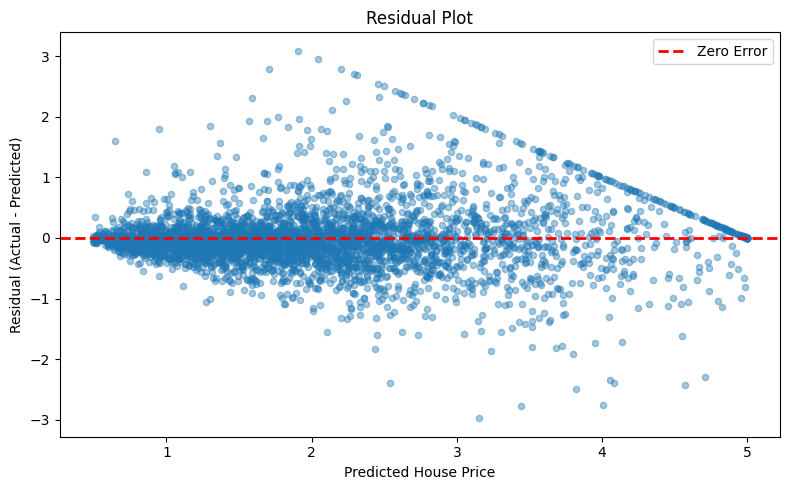

In [44]:
plt.figure(figsize=(8,5))

plt.scatter(
    rf_predictions,
    residuals,
    alpha=0.4,
    s=20
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Zero Error"
)

plt.legend()

plt.title("Residual Plot")
plt.xlabel("Predicted House Price")
plt.ylabel("Residual (Actual - Predicted)")

plt.tight_layout()

plt.show()

## Conclusion

In this project, three regression models were trained and evaluated to predict California housing prices:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

Linear Regression served as the baseline model and achieved an R² score of 0.5758.

The tree-based ensemble models performed significantly better. Random Forest achieved the best overall performance with:

- MAE: 0.3268
- RMSE: 0.5040
- R² Score: 0.8062

Gradient Boosting produced similar results with an R² score of 0.8004.

The results show that housing prices contain nonlinear relationships that are better captured by ensemble tree-based models than by Linear Regression.

Feature importance analysis showed that Median Income was the most influential predictor, while geographic variables such as Latitude and Longitude also played an important role.

The Actual vs Predicted and Residual plots indicate that the Random Forest model provides strong predictions, although prediction errors increase for some higher-priced properties. The capped maximum target value in the dataset also creates visible patterns in the diagnostic plots.

Overall, Random Forest Regressor was selected as the best-performing model for this project.